<a href="https://colab.research.google.com/github/Mensah-D/01_ml_projects/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf
from tensorflow import keras
import tensorflow_datasets as tfds

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
print("TensorFlow's version used in notebook:{}".format(tf.__version__))
print("TensorFlow datasets' version used in notebook{}".format(tfds.__version__))

TensorFlow's version used in notebook:2.19.0
TensorFlow datasets' version used in notebook4.9.9


In [5]:
#Load data from TFDS
(train_data, val_data, test_data), info = tfds.load('cifar10',
                                                    split=['train', 'test[:50%]', 'test[50%:]'],
                                                    as_supervised=True,
                                                    shuffle_files=False,
                                                    with_info=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.C8893E_3.0.2/cifar10-train.tfrecord*...:   0%|         …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.C8893E_3.0.2/cifar10-test.tfrecord*...:   0%|          …

Dataset cifar10 downloaded and prepared to /root/tensorflow_datasets/cifar10/3.0.2. Subsequent calls will reuse this data.


In [6]:
#Checking size of the dataset
print("The Number images in training set: {}".format(len(train_data)))
print("The number images in validation set: {}".format(len(val_data)))
print("The number images in test set: {}".format(len(test_data)))

info.splits['train'].num_examples
info.splits['test'].num_examples

info.features['label'].names
info.features['label'].num_classes

The Number images in training set: 50000
The number images in validation set: 5000
The number images in test set: 5000


10

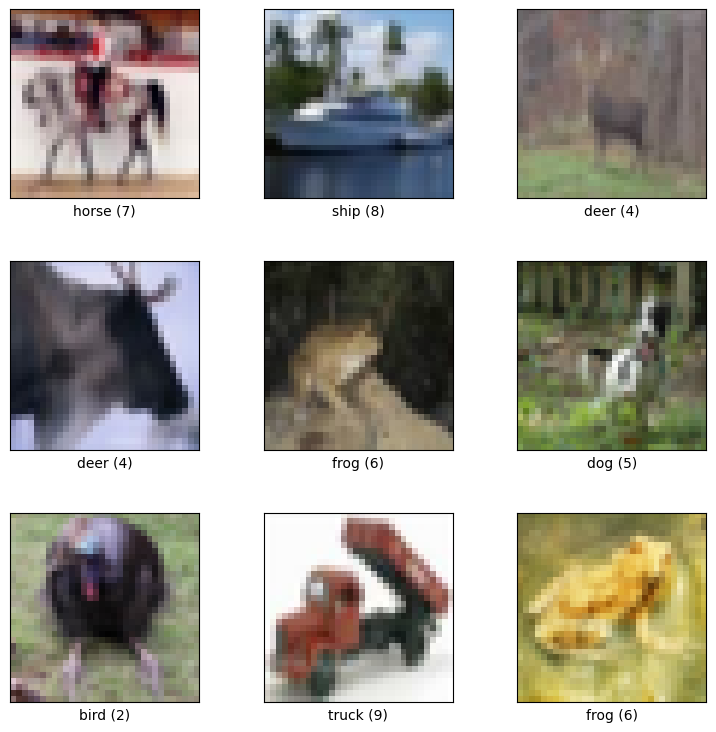

In [7]:
#Checking images
fig=tfds.show_examples(train_data, info)


In [8]:
#Preparing data
#Normalizing images
def preprocess(image, label):
    normalized_img=tf.cast(image, tf.float32)/255.0
    return normalized_img, label

def train_data_prep(data, shuffle_size, batch_size):

    data = data.map(preprocess)
    data = data.cache()
    data = data.shuffle(shuffle_size).repeat()
    data = data.batch(batch_size)
    data = data.prefetch(1)

    return data

def test_data_prep(data, batch_size):
    data = data.map(preprocess)
    data = data.batch(batch_size)
    data = data.cache()
    data = data.prefetch(1)

    return data


In [9]:
train_data_prepared = train_data_prep(train_data, 1000, 32)

test_data_prepared = test_data_prep(test_data, 32)

val_data_prepared = test_data_prep(val_data, 32)

In [10]:
#Model
input_shape = [32,32,3]


cifar_cnn = tf.keras.models.Sequential([
    # First Convolutional layer: 64 filters, kernel/filter size of 3

    tf.keras.layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu', input_shape=input_shape),

    # First Pooling layer
    tf.keras.layers.MaxPooling2D(pool_size=2),

    # Second Convolutional layer & Pooling

    tf.keras.layers.Conv2D(filters=128, kernel_size=(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=2),

    # Third Convolutional & Pooling layer

    tf.keras.layers.Conv2D(filters=256, kernel_size=(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=2),

    # Flattening layer: For converting previous output into 1D column vector

    tf.keras.layers.Flatten(),

    # Fully Connected layers

    tf.keras.layers.Dense(units=128, activation='relu'),
    tf.keras.layers.Dense(units=64, activation='relu'),

    # Last layer: 10 neurons for 10 classes, activated by softmax
    tf.keras.layers.Dense(units=10, activation='softmax')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
#Model summary
cifar_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 510,922 (1.95 MB)

 Trainable params: 510,922 (1.95 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
cifar_cnn.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

In [13]:
#Compiling the model
batch_size = 32
train_size = info.splits["train"].num_examples

val_size = len(val_data_prepared)

train_steps = int(train_size/batch_size)
val_steps = int(val_size/batch_size)

model_history = cifar_cnn.fit(train_data_prepared,
                              validation_data=val_data_prepared,
                              epochs=9,
                              steps_per_epoch=train_steps,
                              validation_steps=val_steps)

Epoch 1/9
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 219s 139ms/step - accuracy: 0.4388 - loss: 1.5165 - val_accuracy: 0.6016 - val_loss: 1.2412
Epoch 2/9
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 203s 130ms/step - accuracy: 0.6105 - loss: 1.0958 - val_accuracy: 0.5859 - val_loss: 1.0363
Epoch 3/9
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 203s 130ms/step - accuracy: 0.6798 - loss: 0.9128 - val_accuracy: 0.6484 - val_loss: 1.0385
Epoch 4/9
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 205s 131ms/step - accuracy: 0.7266 - loss: 0.7826 - val_accuracy: 0.6562 - val_loss: 1.0386
Epoch 5/9
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 202s 130ms/step - accuracy: 0.7592 - loss: 0.6911 - val_accuracy: 0.6875 - val_loss: 0.9653
Epoch 6/9
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 203s 130ms/step - accuracy: 0.7893 - loss: 0.6074 - val_accuracy: 0.7109 - val_loss: 0.9147
Epoch 7/9
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 202s 129ms/step - accuracy: 0.8114 - loss: 0.5390 - val_accuracy: 0.6875 - val_loss: 1.0279
Epoch 8/9
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 203s 130ms/step - accuracy: 

<Axes: >

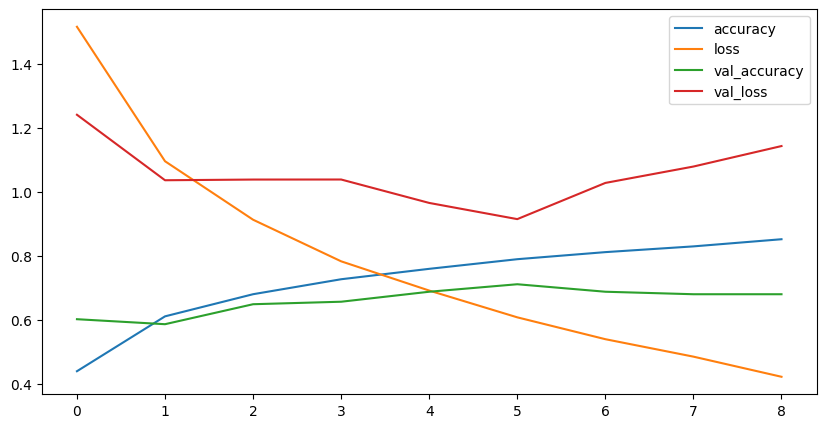

In [14]:
import pandas as pd

 # Getting the model training history
model_history = model_history.history

# Model history into a pandas dataframe
loss_acc_df = pd.DataFrame(model_history)

# Plotting the loss and accuracy

loss_acc_df.plot(figsize=(10,5))

In [15]:
acc = model_history['accuracy']
val_acc = model_history['val_accuracy']
loss = model_history['loss']
val_loss = model_history['val_loss']

epochs = cifar_cnn.history.epoch

# function to plot accuracy

def plot_acc(acc, val_acc, epochs):
  plt.figure(figsize=(10,5))
  plt.plot(epochs, acc, 'r', label='Training Accuracy')
  plt.plot(epochs, val_acc, 'g', label='Validation Accuracy')
  plt.title('Training and validation accuracy')
  plt.legend(loc=0)
  plt.figure()

def plot_loss(loss, val_loss, epochs):
  plt.figure(figsize=(10,5))
  plt.plot(epochs, loss, 'b', label='Training Loss')
  plt.plot(epochs, val_loss, 'y', label='Validation Loss')
  plt.title('Training and Validation Loss')
  plt.legend(loc=0)
  plt.figure()

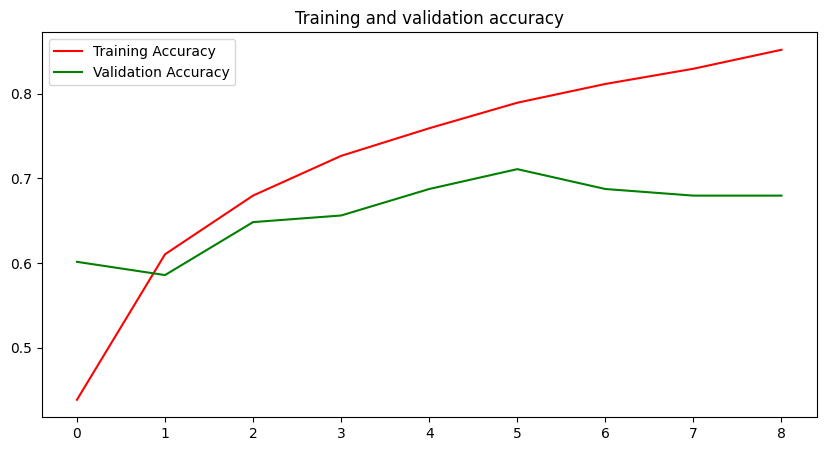

<Figure size 640x480 with 0 Axes>

In [16]:
#Plotting acc
plot_acc(acc, val_acc, epochs)

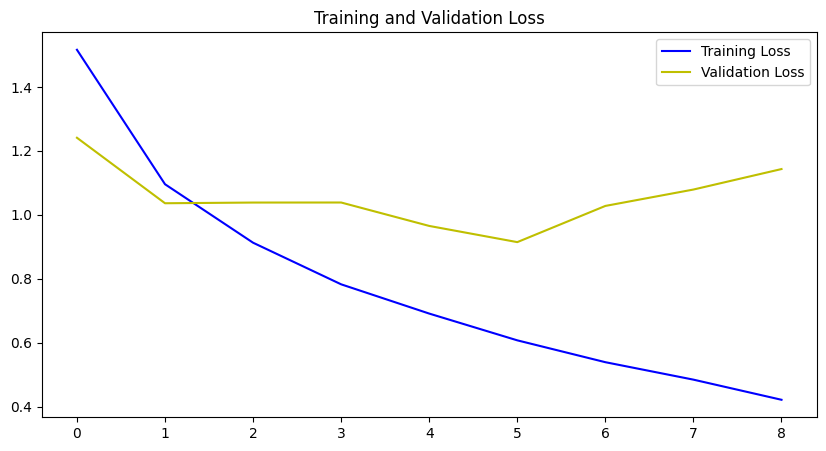

<Figure size 640x480 with 0 Axes>

In [17]:
plot_loss(loss, val_loss, epochs)

In [18]:
# Reloading the data
(train_data, val_data, test_data), info = tfds.load('cifar10',
                                                    split =['train[:80%]', 'train[80%:]','test'],
                                                    as_supervised=True,
                                                    shuffle_files=True,
                                                    with_info=True)

In [19]:
train_final = train_data_prep(train_data, 1000, 32)

val_final = test_data_prep(val_data, 32)
test_final = test_data_prep(test_data, 32)

In [20]:
input_shape = [32, 32, 3]

cifar_cnn_2 = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu', input_shape=input_shape),
    tf.keras.layers.MaxPooling2D(pool_size=2),

    tf.keras.layers.Conv2D(filters=128, kernel_size=(3,3), padding='same', activation ='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=2),

    tf.keras.layers.Conv2D(filters=256, kernel_size=(3,3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(units=128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(units=10, activation='softmax')
])

cifar_cnn_2.compile(loss='sparse_categorical_crossentropy',
                    optimizer='nadam',
                    metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
#Training the model for 10 epochs
batch_size = 32
train_size = 40000
val_size = 10000

train_steps = int(train_size/batch_size)
val_steps = int(val_size/batch_size)

model_history_2 = cifar_cnn_2.fit(train_final,
                              validation_data=val_final,
                              epochs=10,
                              steps_per_epoch=train_steps,
                              validation_steps=val_steps)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 316s 251ms/step - accuracy: 0.4223 - loss: 1.5756 - val_accuracy: 0.5870 - val_loss: 1.1549
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 303s 243ms/step - accuracy: 0.5737 - loss: 1.1999 - val_accuracy: 0.6657 - val_loss: 0.9721
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 302s 242ms/step - accuracy: 0.6305 - loss: 1.0465 - val_accuracy: 0.7017 - val_loss: 0.8515
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 323s 258ms/step - accuracy: 0.6685 - loss: 0.9506 - val_accuracy: 0.7093 - val_loss: 0.8178
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 301s 241ms/step - accuracy: 0.6914 - loss: 0.8818 - val_accuracy: 0.7325 - val_loss: 0.7544
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 322s 258ms/step - accuracy: 0.7139 - loss: 0.8294 - val_accuracy: 0.7461 - val_loss: 0.7260
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 323s 258ms/step - accuracy: 0.7274 - loss: 0.7847 - val_accuracy: 0.7452 - val_loss: 0.7504
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 302s 241ms/step - ac

In [25]:
#Plot loss and accuracy
model_history = model_history_2.history

acc = model_history['accuracy']
val_acc = model_history['val_accuracy']
loss = model_history['loss']
val_loss = model_history['val_loss']

epochs = model_history_2.epoch

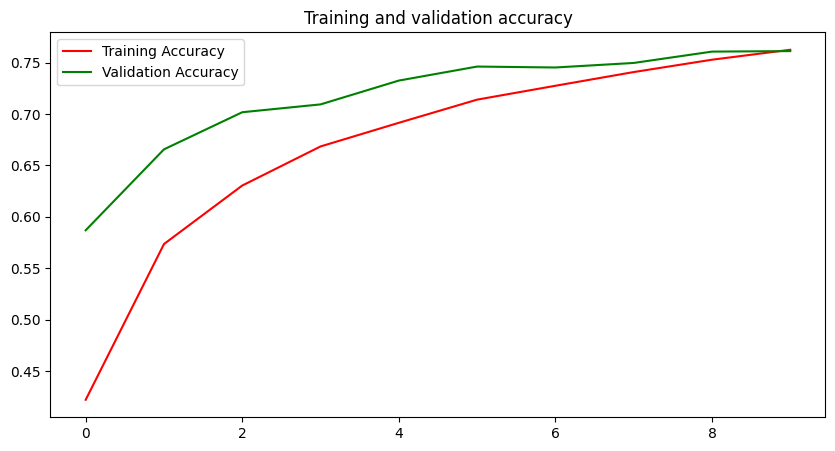

<Figure size 640x480 with 0 Axes>

In [27]:
plot_acc(acc,val_acc, epochs)

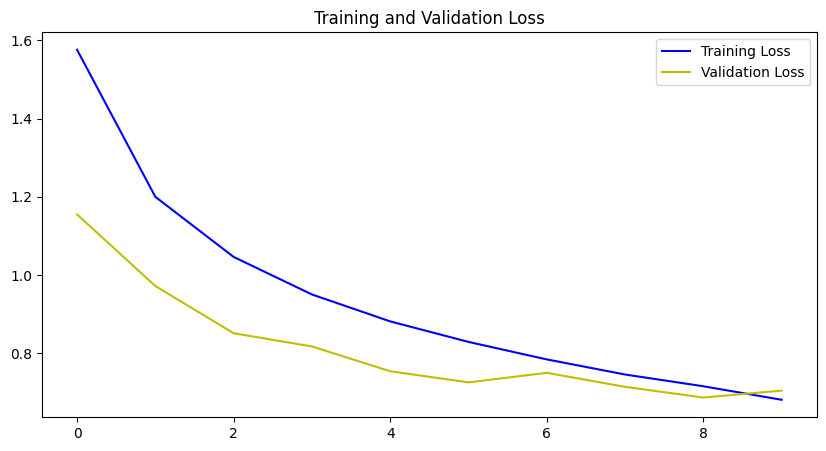

<Figure size 640x480 with 0 Axes>

In [28]:
plot_loss(loss, val_loss, epochs)

In [29]:
#Evaluating on Test set
loss, acc = cifar_cnn_2.evaluate(test_final)

313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 75ms/step - accuracy: 0.7581 - loss: 0.7125


In [30]:
print('Test Loss: {:.3f}'.format(loss))
print('Test Accuracy: {:.3f}'.format(acc))

Test Loss: 0.712
Test Accuracy: 0.758


In [31]:
#Saving and loading the model
cifar_cnn_2.save('Cifar Best.h5')

In [33]:
from keras.models import load_model

load_cifar = load_model('Cifar Best.h5')

In [34]:
load_cifar.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896,525 (3.42 MB)

 Trainable params: 896,522 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3 (16.00 B)